

# Training tranfer learning Staph adage models for GLEAn

#### Georgia Doing, <doingg@union.edu>

#### July 31, 2026

This notebook trains adage models on S. aureus and S. epidermidis, a couple datasets with 
various hyperparameter choices in order to visualize training dynamics
on training and validation loss as well and hidden layer weight
distributions. 

#### Outline

1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data
3. Train some models with hyperparameters from previous search
4. Plot training loss over epochs
5. Plot weight distributions of final models



### 1. Loading classes, modules

In [1]:
# for adage models
from adage import Adage as ad
from adage import SeqAdage

# for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# misc
#from scipy.stats import hypergeom
#import csv
#import random
import time
import tensorflow as tf


2026-07-31 20:13:17.721908: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-31 20:13:17.747077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  0
False


## 2. Plotting training data distributions

Here we are looking at two training datasets. The first is S. aureus and the second is S. epidermidis.

### Sa genes

This compendium has genes in the Sa pangenome and samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

In [3]:
sa_comp = pd.read_csv('../data_files/sa_NCTC3825_filt_norm_log_01.csv', index_col = 0) 
sa_gene_num = np.size(sa_comp, 0)
sa_samp_num = np.size(sa_comp, 1)

In [4]:
print("There are {} genes (features) and {} samples".format(sa_gene_num,
                                                            sa_samp_num))

There are 2766 genes (features) and 2153 samples


In [5]:
sa_comp.head()

,DRX011556,DRX011557,DRX011558,DRX011559,DRX011560,DRX011561,DRX078099,DRX078100,DRX078101,DRX078102,...,SRX13266617,SRX13266618,SRX13266619,SRX13266620,SRX13266621,SRX13266622,SRX13266623,SRX13365952,SRX13365953,SRX13365954
SAOUHSC_00381a,0.000000,0.227596,0.000000,0.201283,0.000000,0.205049,0.135095,0.148972,0.227729,0.189997,...,0.248451,0.205670,0.247376,0.211517,0.213394,0.234742,0.218237,0.000000,0.100215,0.135629
SAOUHSC_01055a,0.326729,0.318854,0.309222,0.230275,0.225963,0.297324,0.330064,0.315903,0.335173,0.309934,...,0.385533,0.354824,0.350810,0.396958,0.410220,0.370967,0.411660,0.389343,0.367482,0.382554
SAOUHSC_1307a,0.210830,0.172425,0.199302,0.201283,0.164376,0.244523,0.224002,0.232896,0.296977,0.235943,...,0.223188,0.173492,0.160138,0.188208,0.188866,0.175345,0.221426,0.345980,0.300787,0.311151
SAOUHSC_1342a,0.433768,0.406363,0.412397,0.385257,0.360783,0.415050,0.515704,0.500993,0.518981,0.431592,...,0.535249,0.458565,0.484540,0.509154,0.530055,0.487420,0.526556,0.469303,0.466695,0.465122
SAOUHSC_01761a,0.113850,0.255401,0.218339,0.140900,0.202962,0.000000,0.263718,0.249371,0.288704,0.244769,...,0.467974,0.408216,0.451086,0.456852,0.479344,0.477565,0.475812,0.281551,0.218020,0.294928


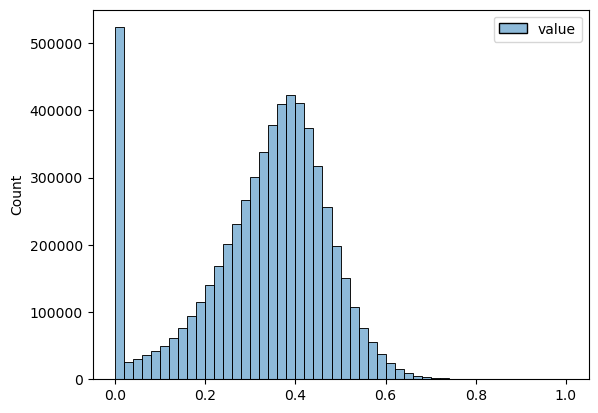

In [6]:
fig = sns.histplot(pd.melt(sa_comp), bins = 50)

### Se genes

This compendium has genes in the Se pangenome and samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

In [7]:
se_comp = pd.read_csv('../data_files/se_se16_epi_comp_log_counts_norm_01.csv', index_col = 0) 
se_gene_num = np.size(se_comp, 0)
se_samp_num = np.size(se_comp, 1)

In [8]:
print("There are {} genes (features) and {} samples".format(se_gene_num,
                                                            se_samp_num))

There are 2266 genes (features) and 239 samples


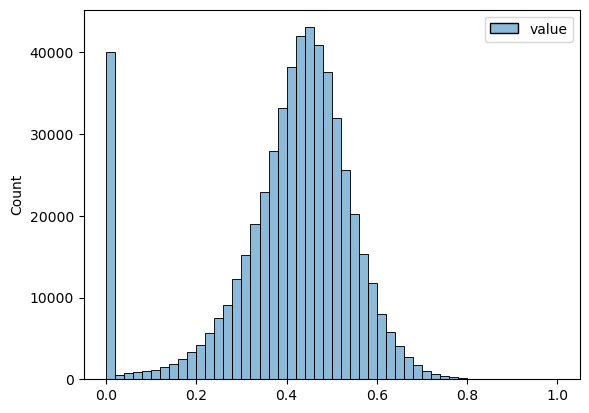

In [9]:
fig = sns.histplot(pd.melt(se_comp), bins = 50)

## Mapping Function

Mapping function is a matrix where the rows are the genes from the pre-training dataset and the columns are the genes from the fine-tuning dataset. The values are 0 or 1 to indicate whther two genes are homologous. Pre-training genes (Sa) can be used to initialized more than one gene in the ultimate fine-tuning dataset (Se), but each gene in the final, fine-tuning dataset (Se) should only source 1 gene from the pre-training set (Sa).

In [10]:
mapper = pd.read_csv('../data_files/se16_sa8325_map_DF01.csv', index_col = 0)
print('Sa genes in mapping')
print(sum(mapper.sum(axis=1) > 0))
print('Se genes in mapping')
print(sum(mapper.sum(axis=0) > 0))

Sa genes in mapping
1828
Se genes in mapping
2052


# 3. Train Transfer models: pre-train on Sa, fine-tune on Se

Note that the hyper-parameters used here are just for demonstration, not the results of tuner analyses.

In [11]:
# a dict to store the models
comps = ["sa_NCTC3825_filt_norm_log_01.csv"]
model_dict_post = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + "se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/' + comp,
                                                  seed=seed+100,
                                                  enc_dim = 200,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=10,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5) 
        pseq = sa.pre_train_model()
        
        # by default keeps the same hyper-parameters, but alternates can be given
        mseq = sa.fine_tune_model('../data_files/se16_sa8325_map_DF01.csv',
                                  "../data_files/se_se16_epi_comp_log_counts_norm_01.csv")
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_se_se16_epi_comp_log_counts_norm_01_2025_09_01_100
Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0368 - val_loss: 0.0153
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0139 - val_loss: 0.0153
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0138 - val_loss: 0.0152
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0138 - val_loss: 0.0152
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0137 - val_loss: 0.0150
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0136 - val_loss: 0.0150
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0134 - val_loss: 0.0149
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0133 - val_loss: 0.0147
Epoch 9/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0132 - val_loss: 0.0147
Epoch 10/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0132 - val_loss: 0.0144
fitted
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1218 - val_loss: 0.0150
Epoch

# 4. Train single Se-only models for comparison

In [12]:
# a dict to store the models
comps = ["se_se16_epi_comp_log_counts_norm_01.csv"]
model_dict_single = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'adSingle_' + "se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('../data_files/' + comp,
                                                  seed=seed+100,
                                                  enc_dim = 200,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=10,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5) 
        mseq = sa.train_model()
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_single[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_100
Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1163 - val_loss: 0.0149
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132 - val_loss: 0.0145
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - val_loss: 0.0145
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132 - val_loss: 0.0146
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - val_loss: 0.0145
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0131 - val_loss: 0.0151
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130 - val_loss: 0.0147
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0129 - val_loss: 0.0144
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130 - val_loss: 0.0146
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 - val_loss: 0.0143
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128 - val_loss: 0.0146
Epo

# 5. Plot loss curves

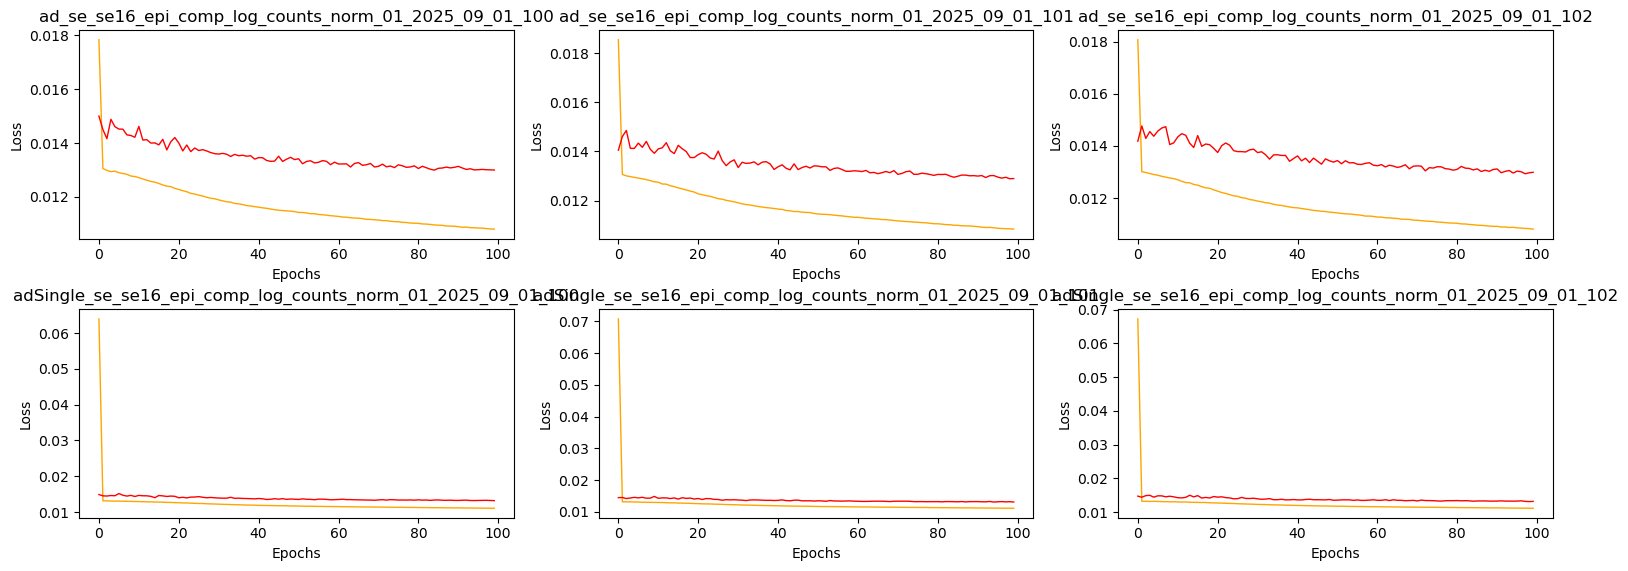

In [13]:
# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*8 ,yd *2))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0


for comp in [""]:
    xi=0
    for seed in seeds:
        name = 'ad' + comp + "_se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1
    xi=0
    for seed in seeds:
        name = 'adSingle' + comp + "_se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_single[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1, 
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss, 
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1

# 6. Plot weight distributions

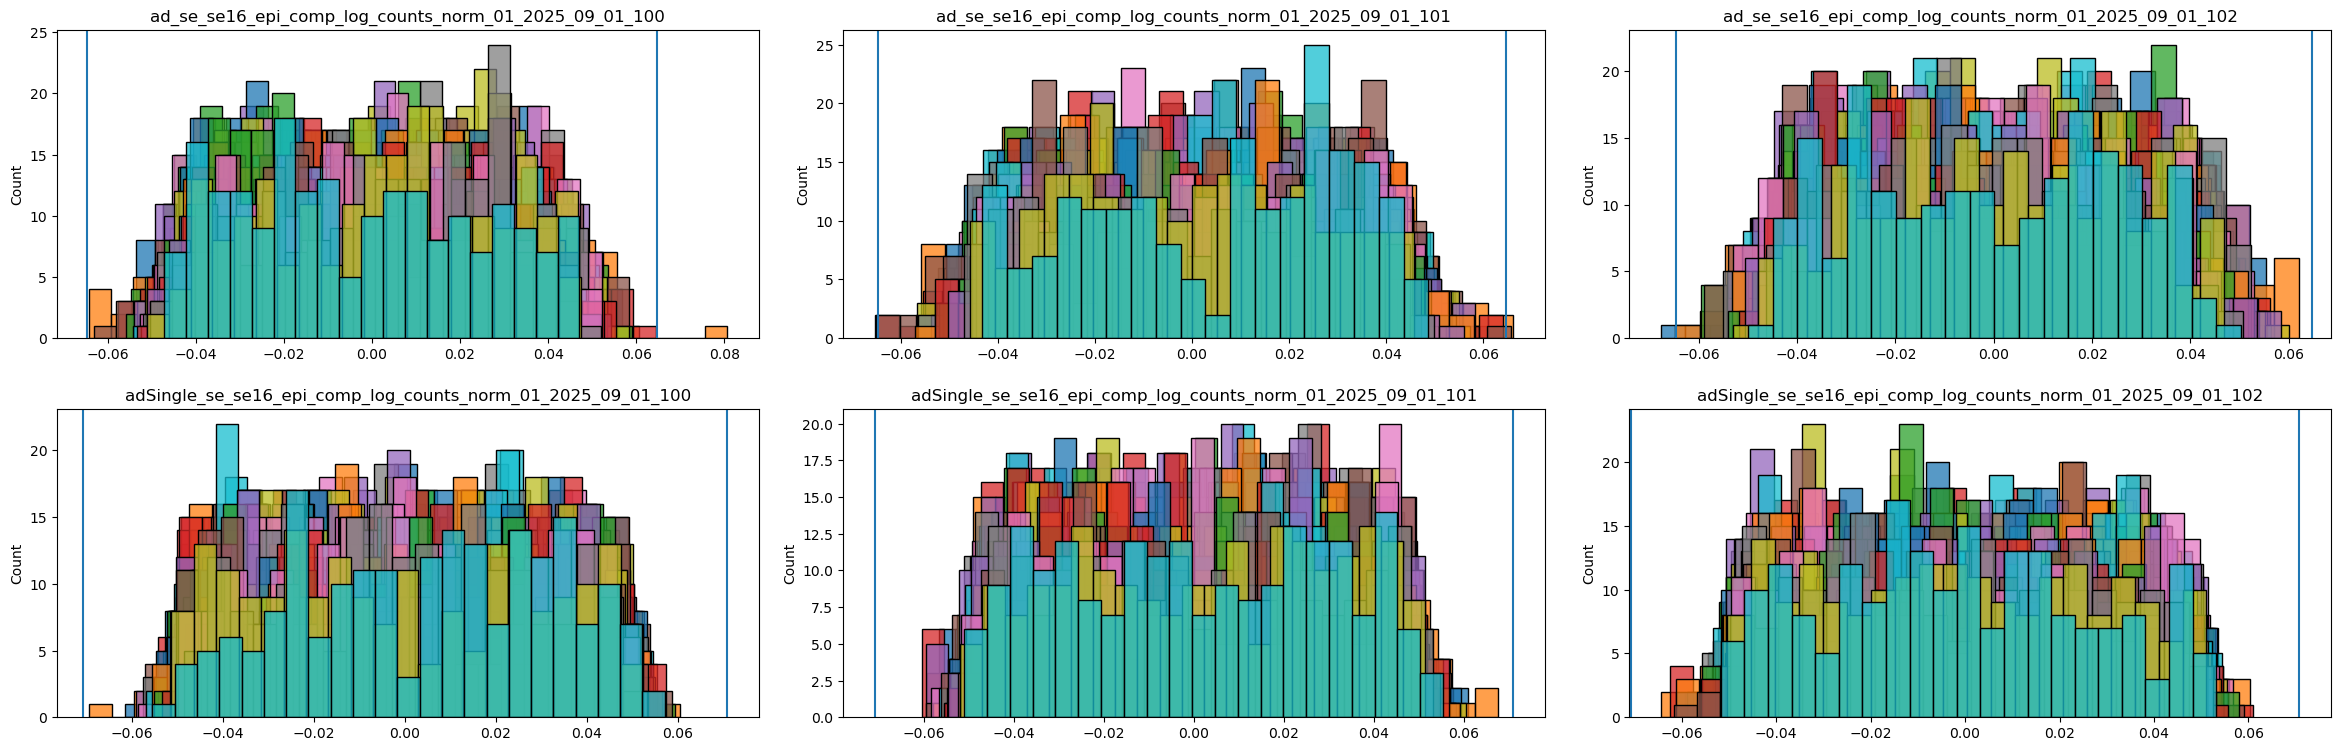

In [14]:
# set layout for panels of compendia and seeds
xd = len(comps) +1
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in [""]:
        name = 'ad' + comp + "_se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    
    #xi=0
    for comp in [""]:
        name = 'adSingle' + comp + "_se_se16_epi_comp_log_counts_norm_01.csv"[:-4] + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_single[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node], 
                ax=ax[xi,yi],
                binwidth = 0.005, 
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1
    xi=0

# KEGG enrichment

In [15]:
for m in model_dict_post:
    print(m)
    model_dict_post[m].set_hwg_cutoff(2.5)
    model_dict_post[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    print('kegg done')

for m in model_dict_single:
    print(m)
    model_dict_single[m].set_hwg_cutoff(2.5)
    model_dict_single[m].set_kegg('../node_interpretation/se16_KEGG_format.txt') 
    print('kegg done')

print('dict done') 

ad_se_se16_epi_comp_log_counts_norm_01_2025_09_01_100
kegg done
ad_se_se16_epi_comp_log_counts_norm_01_2025_09_01_101
kegg done
ad_se_se16_epi_comp_log_counts_norm_01_2025_09_01_102
kegg done
adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_100
kegg done
adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_101
kegg done
adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_102
kegg done
dict done


## Plot enriched KEGG pathways

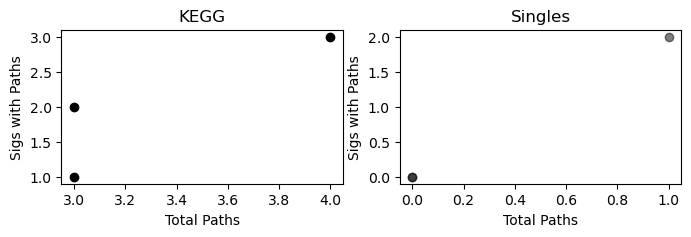

In [16]:

xd=1
yd=2
fig, ax = plt.subplots(xd,yd,figsize=(yd*4 ,xd *2))


for m in model_dict_post.keys():
    model_temp = model_dict_post[m]
    x = ((model_temp.kegg_ps > 1).sum(0) > 0).sum()
    y = ((model_temp.kegg_ps > 1).sum(1) > 0).sum()
    ax[0].scatter(x, y, color = "black")
    ax[0].set(title = 'KEGG', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')

t_mods = ['adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_102', 
          'adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_101',
          'adSingle_se_se16_epi_comp_log_counts_norm_01_2025_09_01_100']

for m in model_dict_single.keys():
    model_temp = model_dict_single[m]
    x = ((model_temp.kegg_ps > 1).sum(0) > 0).sum()
    y = ((model_temp.kegg_ps > 1).sum(1) > 0).sum()
    ax[1].scatter(x, y,alpha=0.5, color = "black")
    ax[1].set(title = 'Singles', xlabel = 'Total Paths', ylabel = 'Sigs with Paths')


